In [1]:
import os
import pandas as pd
import numpy as np
import importlib
import pickle

from Soccer_OCEL.idsse_import import get_games, load_game_data
from Soccer_OCEL.role_objects import assign_roles_multi
import Soccer_OCEL.utils as utils

from pm4py.objects.ocel.util.log_ocel import log_to_ocel_multiple_obj_types
import pm4py

from pm4py.algo.discovery.dfg.variants import clean_time
from pm4py.visualization.dfg.variants import timeline as timeline_gviz_generator
from pm4py.visualization.dfg import visualizer as dfg_visualizer

In [2]:
import geopandas as gpd
import shapely.geometry as geometries

In [ ]:
s = geopandas.GeoSeries([Polygon([(0, 0), (1, 1), (0, 1)]), None, Polygon([])], crs="EPSG:3857")


between_time(start_time, end_time[, ...])

Select values between particular times of the day (e.g., 9:00-9:30 AM).

In [4]:
path='data/28196177'
#games=get_games(path)
games=['J03WQQ', 'J03WR9', 'J03WPY', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf
#games=['J03WQQ', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf, won games
#games=['J03WR9', 'J03WPY']#Fortuna Düsseldorf lost game
all_games=[]
for Game in games:
    with open(os.path.join('output','output_pkl',f"GameData_{Game}_simplified_teamed_epos.pkl"), "rb") as f:
        GD_loaded = pickle.load(f)
    all_games.append(GD_loaded.events)
allgame_df=pd.concat(all_games).sort_values('time:timestamp').reset_index(drop=True)

In [9]:
gdf = gpd.GeoDataFrame(
    allgame_df,
    geometry=gpd.points_from_xy(allgame_df["attribute:x"], allgame_df["attribute:y"])
)

In [10]:
gdf

,level_0,concept:name,attribute:gameclock,tID,Player,attribute:outcome,time:timestamp,minute,second,attribute:qualifier,...,PenaltyExecution,PenaltyDirection,AssistFouledPlayer,TypeOfPossessionLoss,PossessionLossOrigin,ChangeOfCaptain,ChangeContingentExhausted,PlayerBecomesGoalkeeper,Error,geometry
0,0.0,Pass,0.00,DFL-CLU-000011,DFL-OBJ-002GAB,NaN,2022-08-26 16:32:08.110000+00:00,0.0,0.0,"{'GameSection': 'firstHalf', 'TeamRight': 'DFL...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (52.94 34.1)
1,NaN,Central Advance,0.04,NaN,DFL-OBJ-002GEE,NaN,2022-08-26 16:32:08.150000+00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (32.44 45.81)
2,NaN,Wing Advance,0.04,NaN,DFL-OBJ-002G2Y,NaN,2022-08-26 16:32:08.150000+00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (52.92 59.16)
3,NaN,Central Transition,0.04,NaN,DFL-OBJ-0028SW,NaN,2022-08-26 16:32:08.150000+00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (36.92 19.13)
4,NaN,Holding Central Midfield,0.04,NaN,DFL-OBJ-002GAB,NaN,2022-08-26 16:32:08.150000+00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (52.94 34.1)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21666,NaN,Lateral Repositioning,3106.76,NaN,DFL-OBJ-002G0F,NaN,2022-11-11 19:23:38.220000+00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (47.07 24.69)
21667,NaN,Lateral Repositioning,3112.28,NaN,DFL-OBJ-002GPN,NaN,2022-11-11 19:23:43.740000+00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (46.52 34.11)
21668,NaN,Wing Transition,3114.08,NaN,DFL-OBJ-002FXT,NaN,2022-11-11 19:23:45.540000+00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (70.35 23.21)
21669,1384.0,Penalty_ShotAtGoal,3050.34,DFL-CLU-00000I,DFL-OBJ-00017G,1.0,2022-11-11 19:24:13.360000+00:00,50.0,50.0,"{'RefDecisionEvaluation': 'controversial', 'Te...",...,targetedShot,101,DFL-OBJ-002GPI,NaN,NaN,NaN,NaN,NaN,NaN,POINT (96.31 33.85)


<Axes: >

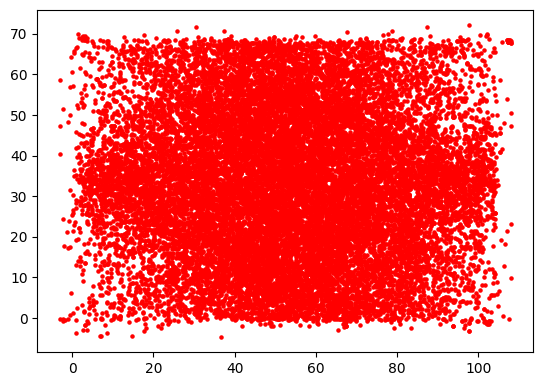

In [12]:
gdf.plot(color='red', markersize=5)

In [3]:
path='data/28196177'
#games=get_games(path)
#games=['J03WQQ', 'J03WR9', 'J03WPY', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf
#games=['J03WQQ', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf, won games
games=['J03WR9', 'J03WPY']#Fortuna Düsseldorf lost game
GD=[]
for Game in games:
    print(f'Getting {Game}')
    GameData=load_game_data(path, Game, event_based_possession=True, get_position_events=True, pass_direction=True)
    GameData=assign_roles_multi(GameData, team=True)
    GameData = utils.formatting(GameData)
    GD.append(GameData)

Getting J03WR9


/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/floodlight/core/events.py:80: UserWarning: The 'gameclock' column does not match the defined value range (from floodlight.core.definitions). This may lead to unexpected behavior of methods using this column.
  warnings.warn(


Getting J03WPY


In [6]:
GameData.events['trajectory']

0                                                     NaN
1       LINESTRING (50.38 43.85, 50.38 43.85, 50.38 43...
2       LINESTRING (51.66 1.7899999999999991, 51.61 1....
3       LINESTRING (77.55 33.72, 77.56 33.72, 77.57 33...
4       LINESTRING (58.05 35.41, 58.05 35.41, 58.05 35...
                              ...                        
4494                                                  NaN
4495                                                  NaN
4496                                                  NaN
4497                                                  NaN
4498                                                  NaN
Name: trajectory, Length: 4499, dtype: object

In [7]:
gdf = gpd.GeoDataFrame(
    GameData.events,
    geometry=GameData.events['trajectory'])

In [22]:
from shapely.geometry import Polygon, LineString, Point

length = 105
width = 68
penalty_depth = 16.5
penalty_width = 40.3
goal_depth = 5.5
goal_width = 18.32
center_radius = 9.15
penalty_spot = 11

field = Polygon([
    (0,0),
    (length,0),
    (length,width),
    (0,width)
])

left_half = Polygon([
    (0,0),
    (length/2,0),
    (length/2,width),
    (0,width)
])

right_half = Polygon([
    (length/2,0),
    (length,0),
    (length,width),
    (length/2,width)
])

center_line = LineString([
    (length/2,0),
    (length/2,width)
])

center_circle = Point(length/2, width/2).buffer(center_radius)
y1_goal = (width - goal_width)/2
y2_goal = (width + goal_width)/2

left_goal_area = Polygon([
    (0, y1_goal),
    (goal_depth, y1_goal),
    (goal_depth, y2_goal),
    (0, y2_goal)
])

right_goal_area = Polygon([
    (length-goal_depth, y1_goal),
    (length, y1_goal),
    (length, y2_goal),
    (length-goal_depth, y2_goal)
])

y1_pen = (width - penalty_width)/2
y2_pen = (width + penalty_width)/2

left_penalty_area = Polygon([
    (0, y1_pen),
    (penalty_depth, y1_pen),
    (penalty_depth, y2_pen),
    (0, y2_pen)
])

right_penalty_area = Polygon([
    (length-penalty_depth, y1_pen),
    (length, y1_pen),
    (length, y2_pen),
    (length-penalty_depth, y2_pen)
])

left_penalty_spot = Point(penalty_spot, width/2)
right_penalty_spot = Point(length-penalty_spot, width/2)


field_gdf = gpd.GeoDataFrame({
    "name":[
        "field",
        "left_half",
        "right_half",
        "center_line",
        "center_circle",
        "left_goal_area",
        "right_goal_area",
        "left_penalty_area",
        "right_penalty_area"
        #,
        #"left_penalty_spot",
        #"right_penalty_spot"
    ],
    "geometry":[
        field,
        left_half,
        right_half,
        center_line,
        center_circle,
        left_goal_area,
        right_goal_area,
        left_penalty_area,
        right_penalty_area
        #,
        #left_penalty_spot,
        #right_penalty_spot
    ]
})

<Axes: >

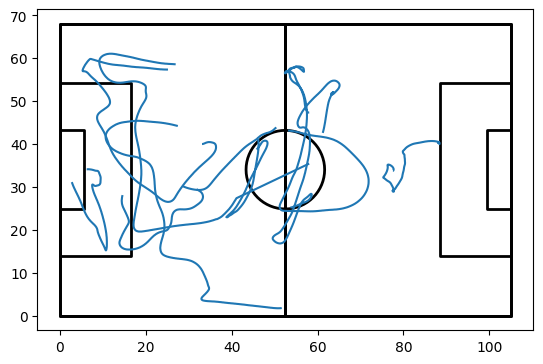

In [25]:
base=field_gdf.plot(facecolor="none", edgecolor="black", linewidth=2)
#base = field_gdf.boundary.plot(color="black", linewidth=2)
gdf[:11].plot(ax=base)